# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [483]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

from scipy.stats import wilcoxon
from numpy import matlib
from scipy.stats.distributions import chi2
from sklearn.model_selection import KFold

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Time Warping is necessary, or there would be falsely detected functional connection

## Creating ground truth with GLM neurons

In [803]:
def toy_model_fr(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = (np.log(features["bump_amp"])-np.log(features["baseline"]))\
        *np.exp(-((time_line-features["bump_center"])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def toy_model_fr_warping(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = (np.log(features["bump_amp"])-np.log(features["baseline"]))*np.exp(-((time_line[:, np.newaxis]- \
                                                      features["bump_center"][np.newaxis, :])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def generate_spike_train(fr, rep=1):
    if fr.ndim == 1:
        return np.random.poisson(lam=np.matlib.repmat(fr[:,np.newaxis],1,rep), size=None)
    else:
        return np.random.poisson(lam=np.matlib.repmat(fr,1,rep), size=None)


In [7]:
def likelihood_ratio_test(nll_diff, df_diff):
    return chi2.sf(2*nll_diff, df_diff)


In [806]:
source = {"baseline": 0.01, "bump_center": np.nan, "bump_amp": 0.1, "bump_wid": 20}
target = {"baseline": 0.01, "bump_center": np.nan, "bump_amp": 0.1, "bump_wid": 20}
bump_center_mean = [240, 260]
bump_center_cov = np.array([[2500, 2250], [2250, 2500]])

nneuron = 1
nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 100 # 5000 trials in total

spike_trains_source = []
spike_trains_target = []
time_line = np.arange(nt)
bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
source["bump_center"] = bump_centers[:, 0]
target["bump_center"] = bump_centers[:, 1]

for ineuron in range(nneuron):
    toy_model_fr_warping(source, time_line)
    spike_trains_source.append( generate_spike_train(source["fr"]) )
    toy_model_fr_warping(target, time_line)
    spike_trains_target.append( generate_spike_train(target["fr"]) )

Text(0.5, 1.0, 'ground truth firing rate')

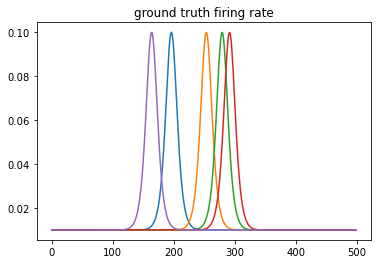

In [807]:
sns.reset_orig()
plt.plot(time_line, target["fr"][:, :5])
plt.title('ground truth firing rate')

## Single neuron level model without conditioning on peak timing

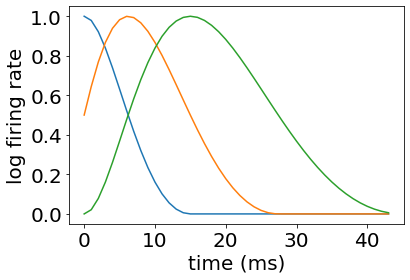

In [1342]:
sns.reset_orig()
_ = GLM.make_pillow_basis(num=3, peaks_max=15, nonlinear=1, verbose=True)

In [654]:
ntimes = 1
nfold = 10

from scipy.stats import wilcoxon

result1 = []
result_pop1 = []
with tqdm(total=ntimes*nfold) as pbar:
    for itimes in range(ntimes):
        test_nll_full = []
        test_nll_nest = []
        test_nll_full_pop = []
        test_nll_nest_pop = []
        nll_diff = 0
        nll_diff_pop = 0

        source = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 2.0, "bump_wid": 20}
        target = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 2.0, "bump_wid": 20}
        bump_center_mean = [240, 260]
        bump_center_cov = np.array([[2500, 2500*0.9], [2500*0.9, 2500]])

        nneuron = 10
        nt = 500
        ntrial = 100
        
        tau = 5
        num_f_refractory = 4

        spike_trains_source = []
        spike_trains_target = []
        time_line = np.arange(nt)
        bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
        source["bump_center"] = bump_centers[:, 0]
        target["bump_center"] = bump_centers[:, 1]

        for ineuron in range(nneuron):
            toy_model_fr_warping(source, time_line)
            spike_trains_source.append( generate_spike_train(source["fr"]) )
            toy_model_fr_warping(target, time_line)
            spike_trains_target.append( generate_spike_train(target["fr"]) )

        kf = KFold(n_splits=nfold)
        for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):

            training_trials = np.array( [False]*ntrial )
            training_trials[train_index] = True
            test_trials = np.logical_not(training_trials)

            ### Single neuron level model
            for output_spike_train in spike_trains_target:

                model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_full.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
                for input_spike_train in spike_trains_source:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=20, nonlinear=1)
                for input_spike_train in spike_trains_target:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=20, nonlinear=1)
                model_full.fit(target=output_spike_train, method='mine', penalty=1e0, verbose=False)
                test_nll_full.append( model_full.test(test_trials) )

                model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_nest.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
                for input_spike_train in spike_trains_target:
                    model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=20, nonlinear=1)
                model_nest.fit(target=output_spike_train, method='mine', penalty=1e0, verbose=False)
                test_nll_nest.append( model_nest.test(test_trials) )
                nll_diff += model_nest.nll - model_full.nll

            ### Population level model
            output_spike_train_pool = np.zeros((nt, ntrial))
            for output_spike_train in spike_trains_target:
                output_spike_train_pool += output_spike_train
            input_spike_train_pool = np.zeros((nt, ntrial))
            for input_spike_train in spike_trains_source:
                input_spike_train_pool += input_spike_train

            model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=20, nonlinear=1)
            model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=20, nonlinear=1)
#             model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
#                                       num=num_f_refractory, apply_no_penalty=True)
            model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=1e-2, verbose=False)
            test_nll_full_pop.append( model_full_pop.test(test_trials) )

            model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=20, nonlinear=1)
#             model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
#                                       num=num_f_refractory, apply_no_penalty=True)
            model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=1e-2, verbose=False)
            test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
            nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
            
            pbar.update(1)

        result1.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
        result_pop1.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

    # result = ranksums( test_nll_full, test_nll_nest, alternative='less'),\
    #             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
    # result_pop = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
    #                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|████████████████████████████████████| 10/10 [02:50<00:00, 17.04s/it]


In [655]:
result1

[WilcoxonResult(statistic=3110.0, pvalue=0.9778594454790771)]

In [656]:
result_pop1

[WilcoxonResult(statistic=37.0, pvalue=0.8388671875)]

<AxesSubplot:ylabel='Count'>

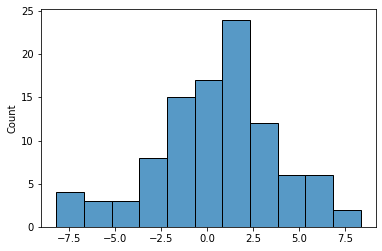

In [657]:
sns.histplot( np.array(test_nll_full) - np.array(test_nll_nest) )

<AxesSubplot:ylabel='Count'>

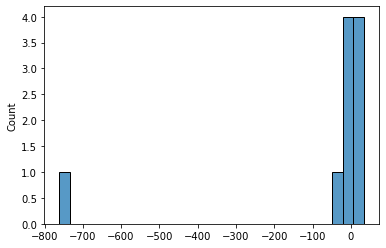

In [658]:
sns.histplot( np.array(test_nll_full_pop) - np.array(test_nll_nest_pop) )

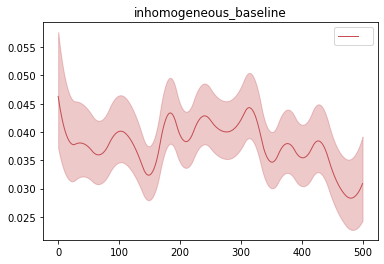

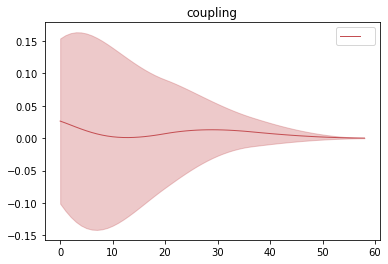

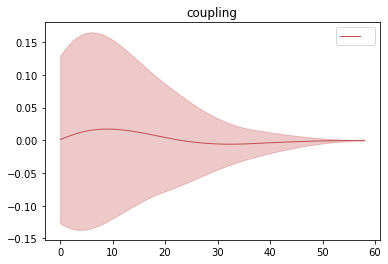

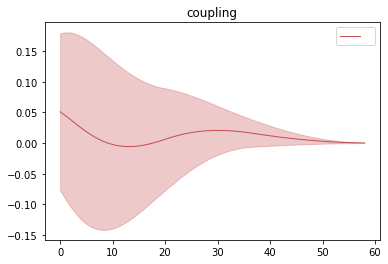

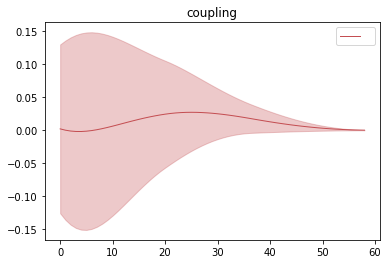

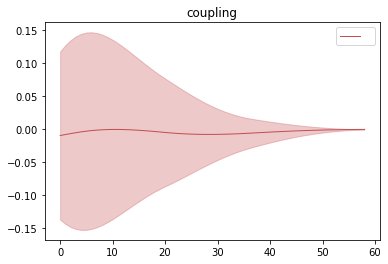

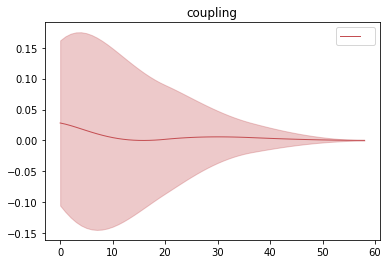

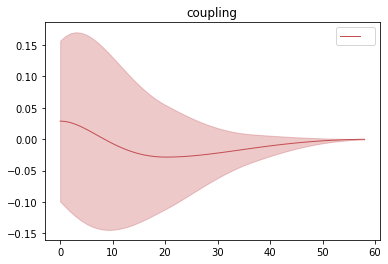

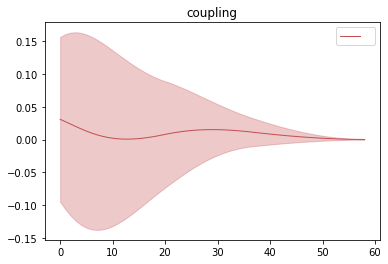

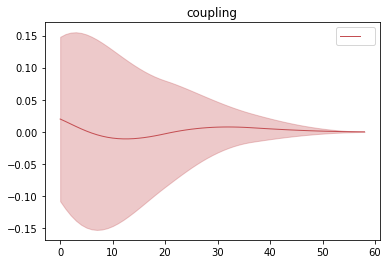

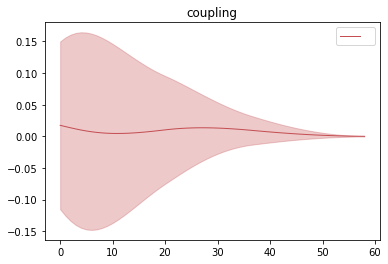

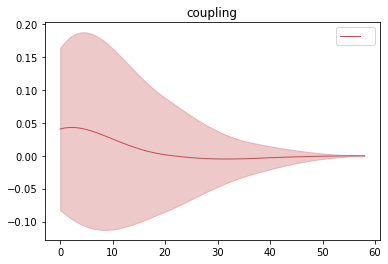

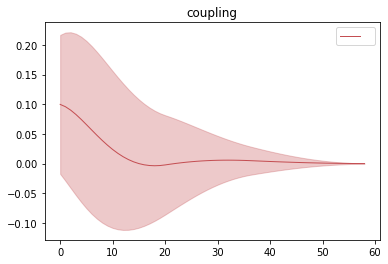

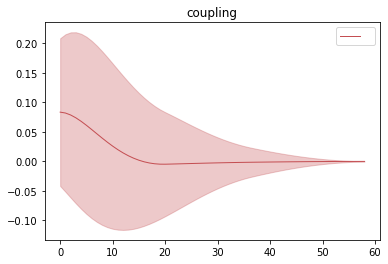

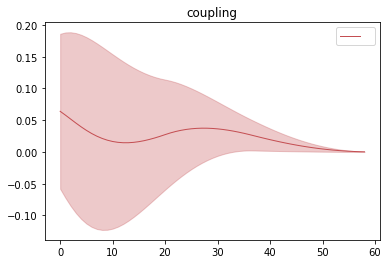

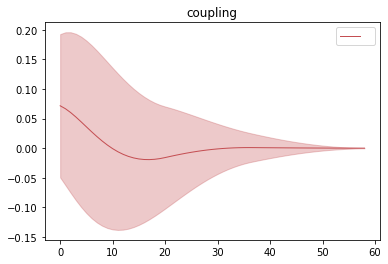

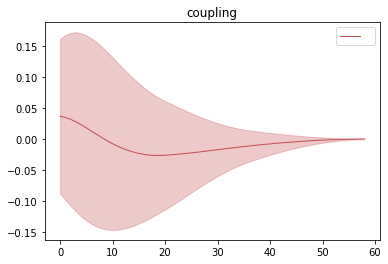

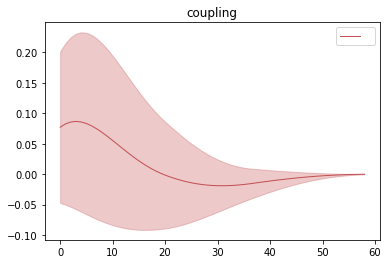

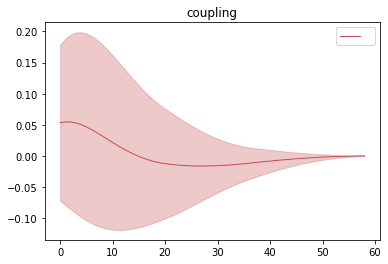

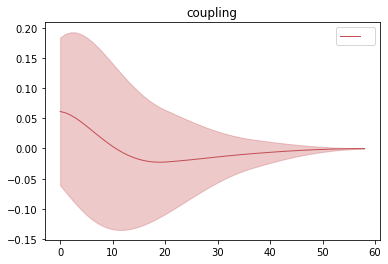

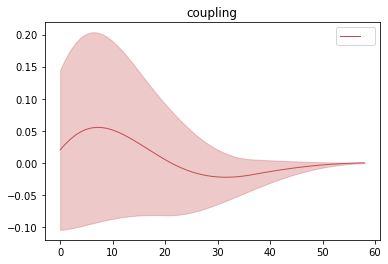

In [659]:
GLM.plot_GLM_compare(model_full)

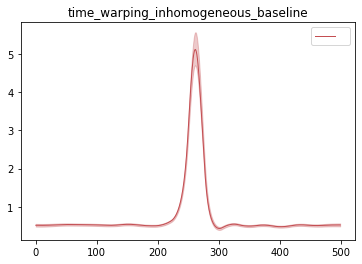

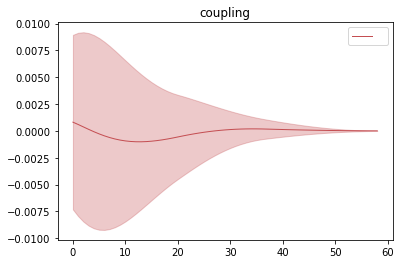

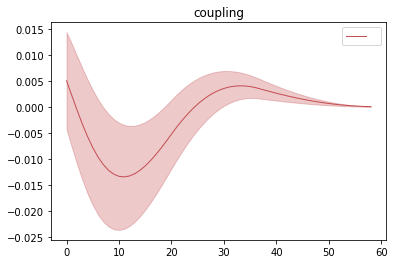

In [660]:
GLM.plot_GLM_compare(model_full_pop)

In [ ]:
# A faster MP version of the code above (0.5h vs 2h)
result, result_pop = GLM.get_ps()

In [ ]:
result

In [ ]:
result_pop

## Plot figures

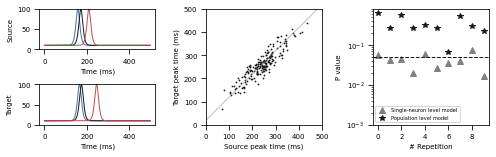

In [1055]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9, 2.2))

color_list = ['b', 'k', 'r']
start = 11
plt.subplot(2,3,1)
for itrial in range(start,start+3):
    plt.plot(time_line, 1e3*source["fr"][:, itrial], color=color_list[itrial-start])
plt.ylabel("Source")
plt.xlabel("Time (ms)")
plt.ylim([0, 100])
# plt.ylabel("Firing rate (spikes/sec)")

plt.subplot(2,3,4)
for itrial in range(start,start+3):
    plt.plot(time_line, 1e3*target["fr"][:, itrial], color=color_list[itrial-start])
plt.ylabel("Target")
plt.xlabel("Time (ms)")
plt.ylim([0, 100])
# plt.ylabel("Firing rate (spikes/sec)")

plt.subplot(1,3,2)
plt.plot(bump_centers[:200, 0],bump_centers[:200, 1], ".", color='k', markersize=1.5)
plt.axline(xy1=(0, 20), slope=1, color='grey', alpha=0.5)
plt.xlim([0, 500])
plt.ylim([0, 500])
plt.xlabel("Source peak time (ms)")
plt.ylabel("Target peak time (ms)")
# plt.title("Peak times")

plt.subplot(1,3,3)
plt.plot([p[1] for p in result], "^", color='grey', label="Single-neuron level model")
plt.plot([p[1] for p in result_pop], "*", color='k', label="Population level model")
plt.axhline(0.05, ls='--', color='k', lw=1)
plt.ylim([1e-3, 0.8])
plt.yscale("log")
plt.legend()
plt.xlabel("# Repetition")
plt.ylabel("P value")
plt.tight_layout()

plt.savefig('Figures/Simulation_study_lower.svg', format='svg', dpi=300)

# Sensitivity

## Plot three panels together

In [1060]:
target = {"baseline": 0.01, "bump_center": 260, "bump_amp": 2.3, "bump_wid": 20}
toy_model_fr(target, time_line)
source = {"baseline": 0.01, "bump_center": 240, "bump_amp": 2.3, "bump_wid": 20}
toy_model_fr(source, time_line)

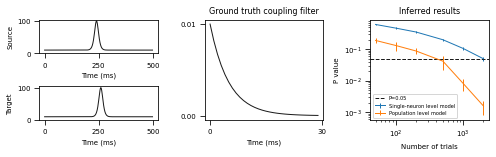

In [1062]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9, 2.2))
ntimes = 10

plt.subplot(2,3,1)
plt.plot(1e3*source["fr"], color='k')
plt.xticks([0, 250, 500])
plt.yticks([0, 100])
plt.xlabel("Time (ms)")
plt.ylabel("Source")
plt.subplot(2,3,4)
plt.plot(1e3*target["fr"], color='k')
plt.xticks([0, 250, 500])
plt.yticks([0, 100])
plt.xlabel("Time (ms)")
plt.ylabel("Target")

plt.subplot(1,3,2)
plt.plot(ground_truth_coupling_filter, color='k')
plt.xticks([0,30])
plt.yticks([0, 1e-2])
plt.xlabel("Time (ms)")
plt.title("Ground truth coupling filter")

plt.subplot(1,3,3)
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 2*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')
yy = (result_mat_pop.mean(axis=1))
yerr = 2*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population level model')
plt.axhline(0.05, ls='--', color='k', lw=1, label="P=0.05")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")
plt.title("Inferred results")
plt.tight_layout()

plt.savefig('Figures/Simulation_study_upper.svg', format='svg', dpi=300)

# Sensitivity

## EIF neuron simulator

In [1034]:
def getI(features, dt, nt):
    time_line = np.arange(nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros(len(time_line))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = (features["bump_amp"][i])*np.exp(-((time_line-features["bump_center"][i])/features["bump_wid"][i])**2)
        features["I"] += stimulus

In [1301]:
def EIF_simulator(ntrial = 100):
    nneuron = 20
    dt = 0.1
    ndt = int(1/dt)
    nt = 500*ndt
    noise_amp = 1

    J = np.zeros((nneuron, nneuron)) # From row i to column j
    nneuron_part = int(nneuron/2)
    J[0:nneuron_part,nneuron_part:] = 0.007
    J[0:nneuron_part,0:nneuron_part] = 0.0
    J[nneuron_part:,nneuron_part:] = 0.0

    baseline = 0.0
    bump_amp = 0.25
    bump_wid = 30
    source = {"baseline": baseline, 
              "bump_center": [50,250], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    target = {"baseline": baseline, 
              "bump_center": [70,260], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    getI(source, dt, nt)
    getI(target, dt, nt)
    I_ext = 0.0*np.ones((nt, nneuron))
    I_ext[:,:nneuron_part] = np.repeat(source["I"][:,np.newaxis],nneuron_part, axis=1)
    I_ext[:,nneuron_part:] = np.repeat(target["I"][:,np.newaxis],nneuron_part, axis=1)

    # Unit: mV or ms
    tau = 15
    EL = -60
    VT = -50
    Vth = -10
    Vre = -65
    DltT = 2
    tau_ref = 1
    tau_d = 5
    tau_r = 1

    nsyn_func = 3*tau_d*ndt
    syn_time_line = np.arange(nsyn_func)
    syn_func = (np.exp(-syn_time_line*dt/tau_d)-np.exp(-syn_time_line*dt/tau_r))[:, np.newaxis]
    ntau_ref = tau_ref*ndt
    V_rcd = np.zeros((nt, nneuron, ntrial))
    I_rcd = np.zeros((nt+nsyn_func+1, nneuron, ntrial))
    spikes_rcd = np.zeros((nt, nneuron, ntrial))

    for itrial in range(ntrial):
        V = Vre*np.ones((nt, nneuron))
        I_syn = np.zeros((nt+nsyn_func+1, nneuron))
        spikes = np.zeros((nt, nneuron))

        for t in range(1, nt):

            I_leak = -dt/tau*(V[t-1,:]-EL) + dt/tau*DltT*np.exp((V[t-1,:]-VT)/DltT)
            I_noise = np.random.normal(0, noise_amp**2, nneuron)
            dV = I_leak + I_noise + I_syn[t,:] + I_ext[t,:]
            V[t,:] = V[t-1,:] + dV

            spikes[t,:] = (V[t,:]>=Vth).astype(int)
            I_syn[(t+1):(t+nsyn_func+1),:] += spikes[t:(t+1),:]@J*syn_func

            in_ref = ((spikes[max(0,t-ntau_ref):(t+1),:].sum(axis=0))>0).astype(int)
            V[t,:] += in_ref*(Vre-V[t,:])

        V_rcd[:,:,itrial] = V
        I_rcd[:,:,itrial] = I_syn
        spikes_rcd[:,:,itrial] = spikes

    spikes_rcd = spikes_rcd.reshape((int(nt/ndt),ndt,nneuron,ntrial), order='C').sum(axis=1)
    return spikes_rcd

spikes_rcd = EIF_simulator()

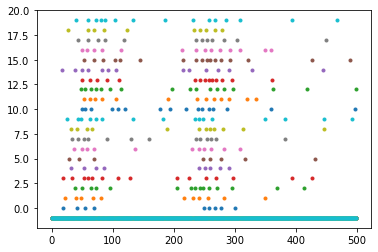

In [1251]:
plt.plot(spikes_rcd[:,:,0]*np.arange(1,nneuron+1)-1, '.')

## Fit the two methods for 100 times

In [1257]:
ntimes = 100
nfold = 10
penalty = 1e5
penalty_pop = 0.5e5
num = 20
num_pop = num
peaks_max = 7

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator()
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < nneuron_part:
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")

# result = wilcoxon( test_nll_full, test_nll_nest, alternative='less'),\
#             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
# result_pop = wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
#                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|███████████████████████████████| 100/100 [5:23:42<00:00, 194.22s/it]


调参：找让pop 和single都pvalue uniform under null的penalty

```
{
penalty = 1e5
penalty_pop = 0.5e5
```
}

Seems fine

<AxesSubplot:ylabel='Count'>

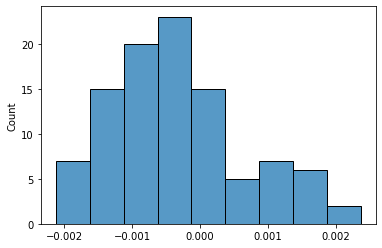

In [1258]:
sns.histplot(np.array(test_nll_full)-np.array(test_nll_nest))

<AxesSubplot:ylabel='Count'>

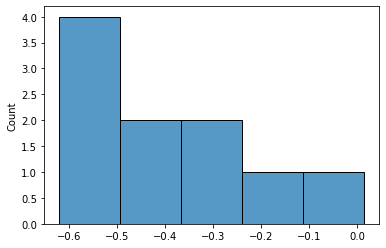

In [1259]:
sns.histplot(np.array(test_nll_full_pop)-np.array(test_nll_nest_pop))

In [1260]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

(0.0, 1.0)

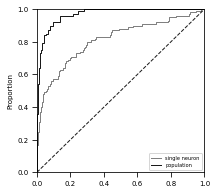

In [1288]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])

Power at alpha=0.05

In [1263]:
np.sum(np.array(p_pop)<=0.05)/len(p_pop)

0.84

In [1264]:
np.sum(np.array(p)<=0.05)/len(p)

0.49

In [1300]:
p_rcd = p
p_pop_rcd = p_pop

## Different number of trials

In [1331]:
ntrial_list = np.logspace(np.log10(25),np.log10(200),7).astype(int)
ntimes = 100
nfold = 10

penalty = 1e5
penalty_pop = 0.5e5
num = 20
num_pop = num
peaks_max = 7

tau = 10
num_f_refractory = 4

result_mat = np.zeros((len(ntrial_list), ntimes))
result_mat_pop = np.zeros((len(ntrial_list), ntimes))

for intrial, ntrial in enumerate(ntrial_list):
    for itimes in tqdm(range(ntimes)):
        test_nll_full = []
        test_nll_nest = []
        test_nll_full_pop = []
        test_nll_nest_pop = []
        nll_diff = 0
        nll_diff_pop = 0

        if itimes!=1:
            spikes_rcd = EIF_simulator(ntrial=ntrial)
        nt, nneuron, ntrial = spikes_rcd.shape

        spike_trains_source = []
        spike_trains_target = []
        time_line = np.arange(nt)

        for ineuron in range(nneuron):
            if ineuron < nneuron_part:
                spike_trains_source.append(spikes_rcd[:,ineuron,:])
            else:
                spike_trains_target.append(spikes_rcd[:,ineuron,:])

        kf = KFold(n_splits=nfold)
        for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):

            training_trials = np.array( [False]*ntrial )
            training_trials[train_index] = True
            test_trials = np.logical_not(training_trials)

            ### Single neuron level model
            for output_spike_train in spike_trains_target:

                model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_full.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
                for input_spike_train in spike_trains_source:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
                for input_spike_train in spike_trains_target:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
                model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
                test_nll_full.append( model_full.test(test_trials) )

                model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_nest.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
                for input_spike_train in spike_trains_target:
                    model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
                model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
                test_nll_nest.append( model_nest.test(test_trials) )
                nll_diff += model_nest.nll - model_full.nll

            ### Population level model
            output_spike_train_pool = np.zeros((nt, ntrial))
            for output_spike_train in spike_trains_target:
                output_spike_train_pool += output_spike_train
            input_spike_train_pool = np.zeros((nt, ntrial))
            for input_spike_train in spike_trains_source:
                input_spike_train_pool += input_spike_train

            model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                      num=num_f_refractory, apply_no_penalty=True)
    #         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
            model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                     method='mine', penalty=penalty_pop, verbose=False)
            test_nll_full_pop.append( model_full_pop.test(test_trials) )

            model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                      num=num_f_refractory, apply_no_penalty=True)
    #         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
            model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                     method='mine', penalty=penalty_pop, verbose=False)
            test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
            nll_diff_pop += model_nest_pop.nll - model_full_pop.nll

        result_mat[intrial, itimes] = wilcoxon( test_nll_full, test_nll_nest, alternative='less')[1]
        result_mat_pop[intrial, itimes] = wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less')[1]

 81%|██████████████████████████▋      | 81/100 [1:03:42<14:53, 47.03s/it]/home/qix/MultiNeuronGLM/GLM.py:1527: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(inv_hessian))
100%|██████████████████████████████| 100/100 [11:48:19<00:00, 424.99s/it]


Text(0, 0.5, 'P value')

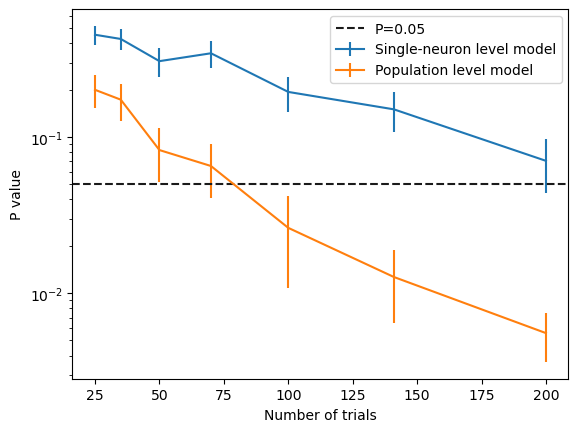

In [1332]:
utils.use_default_plot()
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 2*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')

yy = (result_mat_pop.mean(axis=1))
yerr = 2*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population level model')

plt.axhline(0.05, ls='--', color='k', label="P=0.05")
plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")


Text(0, 0.5, 'Power')

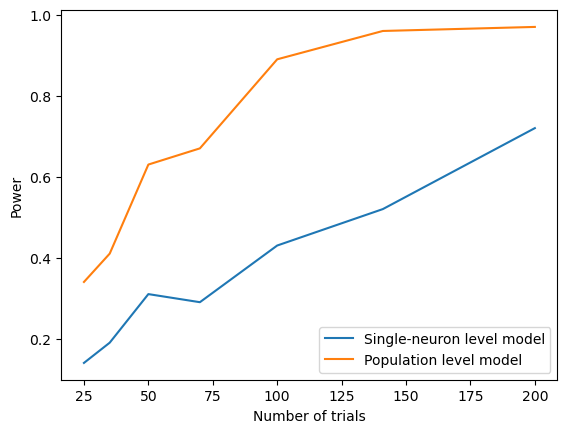

In [1340]:
utils.use_default_plot()
xx = ntrial_list
yy = (result_mat<=0.05).mean(axis=1)
plt.plot(xx, yy, label='Single-neuron level model')

yy = (result_mat_pop<=0.05).mean(axis=1)
plt.plot(xx, yy, label='Population level model')

# plt.axhline(0.95, ls='--', color='k', label="P=0.05")
# plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("Power")


# Experiment on penalty's impact towards nested and full models. 

Penalty is strongly related to the performance of the models and the wilcoxon test results. When penalty is small, a nested model has advantages over full model. When penalty is big, wilcoxon test favors the full model. That's why I tried to find a good penalty for both single neuron level model and population level model for fair comparison. 

In [1139]:
# Find best penalty
ntimes = 1
nfold = 10
penalty_list = np.logspace(-2,7,10)
test_nll_results_full = np.zeros((ntimes, len(penalty_list)))
test_nll_results_nest = np.zeros((ntimes, len(penalty_list)))
test_nll_results_full_pop = np.zeros((ntimes, len(penalty_list)))
test_nll_results_nest_pop = np.zeros((ntimes, len(penalty_list)))

for i, penalty in tqdm(enumerate(penalty_list)):

    num = 20
    num_pop = num
    peaks_max = 7

    tau = 10
    num_f_refractory = 4

    result = []
    result_pop = []

    for itimes in (range(ntimes)):
        test_nll_full = []
        test_nll_nest = []
        test_nll_full_pop = []
        test_nll_nest_pop = []
        nll_diff = 0
        nll_diff_pop = 0

        if itimes!=1:
            spikes_rcd = EIF_simulator()
        nt, nneuron, ntrial = spikes_rcd.shape

        spike_trains_source = []
        spike_trains_target = []
        time_line = np.arange(nt)

        for ineuron in range(nneuron):
            if ineuron < nneuron_part:
                spike_trains_source.append(spikes_rcd[:,ineuron,:])
            else:
                spike_trains_target.append(spikes_rcd[:,ineuron,:])

        kf = KFold(n_splits=nfold)
        for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):

            training_trials = np.array( [False]*ntrial )
            training_trials[train_index] = True
            test_trials = np.logical_not(training_trials)

            ### Single neuron level model
            for output_spike_train in spike_trains_target:

                model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_full.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
                for input_spike_train in spike_trains_source:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
                for input_spike_train in spike_trains_target:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
                model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
                test_nll_full.append( model_full.test(test_trials) )

                model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_nest.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
                for input_spike_train in spike_trains_target:
                    model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
                model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
                test_nll_nest.append( model_nest.test(test_trials) )
                nll_diff += model_nest.nll - model_full.nll

            ### Population level model
            output_spike_train_pool = np.zeros((nt, ntrial))
            for output_spike_train in spike_trains_target:
                output_spike_train_pool += output_spike_train
            input_spike_train_pool = np.zeros((nt, ntrial))
            for input_spike_train in spike_trains_source:
                input_spike_train_pool += input_spike_train

            model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                      num=num_f_refractory, apply_no_penalty=True)
            model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty, verbose=False)
            test_nll_full_pop.append( model_full_pop.test(test_trials) )

            model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                      num=num_f_refractory, apply_no_penalty=True)
            model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty, verbose=False)
            test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
            nll_diff_pop += model_nest_pop.nll - model_full_pop.nll

        result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
        result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )
    
    test_nll_results_full[itimes,i] = np.mean(test_nll_full)
    test_nll_results_nest[itimes,i] = np.mean(test_nll_nest)
    test_nll_results_full_pop[itimes,i] = np.mean(test_nll_full_pop)
    test_nll_results_nest_pop[itimes,i] = np.mean(test_nll_nest_pop)


10it [14:36, 87.64s/it]


In [1141]:
test_nll_results_full

array([[517.24901649, 520.17685424, 524.98562018, 523.66481578,
        538.27391542, 567.0516119 , 568.18152673, 571.96195102,
        568.59456462, 571.20720323]])

In [1160]:
(test_nll_results_full-test_nll_results_nest).flatten()

array([ 1.53725584e+00,  1.37181057e+00,  1.36289485e+00,  5.92523755e-01,
        1.28450155e-01, -2.36806936e-02, -6.24028539e-03, -2.18579709e-04,
       -4.23538252e-05, -1.54945701e-06])

(-0.1, 0.1)

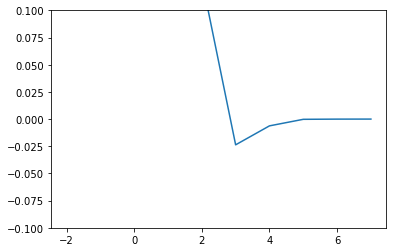

In [1167]:
plt.plot(np.log10(penalty_list), (test_nll_results_full-test_nll_results_nest).flatten())
plt.ylim([-0.1,0.1])

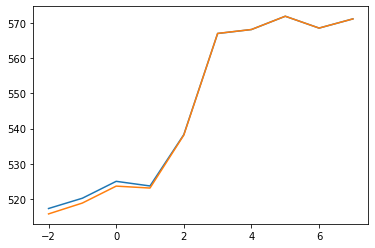

In [1158]:
plt.plot(np.log10(penalty_list), test_nll_results_full.flatten())
plt.plot(np.log10(penalty_list), test_nll_results_nest.flatten())


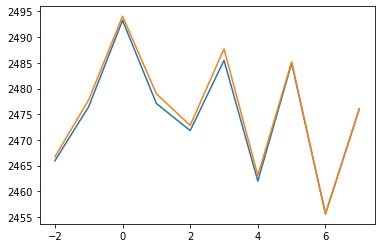

In [1159]:
plt.plot(np.log10(penalty_list), test_nll_results_full_pop.flatten())
plt.plot(np.log10(penalty_list), test_nll_results_nest_pop.flatten())

# Nonparametric bootstrap (why not use the other method Pillow used?)

```
{
I don't think we can use nonparametric bootstrap to compare the two methods. Single neuron model compare whether the distribution of coupling filter integration is the same to the distribution of that under null hypothesis. Population level model compare the mean of estimated coupling filters integration (or excursion statistic) with the mean under null hypothesis. They are different. 
```
}